In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

In [3]:
plt.rcParams['figure.figsize'] = (12,8)
default_plot_color = "#00bfbf"

In [4]:
data = pd.read_csv('133 - fake-news-data.csv')
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


Text(0.5, 0, 'classfication')

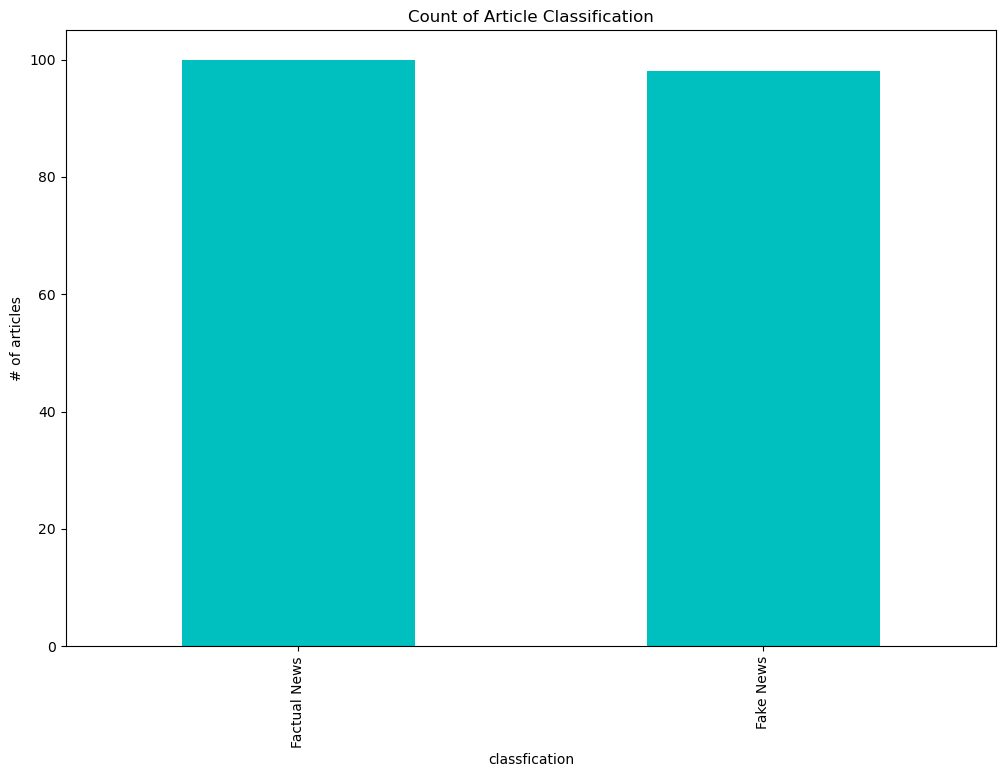

In [6]:
data['fake_or_factual'].value_counts().plot(kind= 'bar', color = default_plot_color)
plt.title('Count of Article Classification')
plt.ylabel('# of articles')
plt.xlabel('classfication')

In [7]:
fake_news = data[data['fake_or_factual'] == 'Fake News'] 
factual_news = data[data['fake_or_factual'] == 'Factual News']
fake_news

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
5,Maxine Waters Makes Teens Chant ‘Impeach 45′ a...,Shame on Teen Vogue! Maxine Waters was a guest...,"Dec 10, 2017",Fake News
6,Jay Carney Let It Slip That He Knows Who Obam...,Former White House Press Secretary in the Obam...,"February 10, 2016",Fake News
...,...,...,...,...
191,Terrorist Jon Ritzheimer Uses Sobbing Daughte...,"Jon Ritzheimer, infamous hater of Muslims and ...","January 26, 2016",Fake News
193,AND SO IT BEGINS…INSPIRED BY GAY MARRIAGE RULI...,"Well, that didn t take long. Look for the firs...","Jul 2, 2015",Fake News
194,‘Stand Your Ground’: FL Man Shoots At Teens P...,Florida s toxic and dangerous stand your grou...,"July 17, 2016",Fake News
195,The Los Angeles Times Endorses Hillary Clinto...,As Politico reports an almost neck-and-neck ra...,"May 30, 2016",Fake News


In [8]:

factual_news

,title,text,date,fake_or_factual
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News
7,"Trump threat fires up U.S. climate activists, ...",(Reuters) - Seattle financial worker Harrison ...,"November 11, 2016",Factual News
9,China labels Trump call 'petty action' by Taiw...,BEIJING (Reuters) - U.S. President-elect Donal...,"December 3, 2016",Factual News
11,Kerry says can't comment on content of Clinton...,QUEBEC CITY (Reuters) - U.S. Secretary of Stat...,"January 29, 2016",Factual News
...,...,...,...,...
184,White House not aware of other nations plannin...,WASHINGTON (Reuters) - The White House said on...,"December 7, 2017",Factual News
185,Four killed as militants attack airport securi...,SRINAGAR (Reuters) - Indian police on Tuesday ...,"October 3, 2017",Factual News
188,Chinese aircraft drill again in Western Pacific,BEIJING (Reuters) - Chinese military aircraft ...,"December 21, 2017",Factual News
192,"France close to Qatar military, transport cont...",PARIS (Reuters) - France is close to finalizin...,"December 4, 2017",Factual News


In [9]:
nlp = spacy.load('en_core_web_sm')

In [10]:
fake_news_doc = list(nlp.pipe(fake_news['text']))
factual_news_doc = list(nlp.pipe(factual_news['text']))
fake_news_doc

[There are two small problems with your analogy Susan  Jesus was NOT a Muslim and Joseph traveled to Bethlehem with Mary. For anyone who s not paying attention there don t appear to be many female refugees accompanying male Muslim  refugees  to Greece.Susan Sarandon spent the Christmas holiday on the Greek island of Lesbos assisting international organizations with the mounting Syrian refugee crisis   a crisis, she says, that recalls the travails of Joseph and Mary on their way to the Inn in Bethlehem.In a column for the Huffington Post and RYOT, the 69-year-old Oscar-winning actress described meeting a 16-year-old girl who had apparently given birth shortly before arriving on the island. I smile and approach her, but without a translator, our conversation is basic-friendly,  Sarandon wrote of her experience.  She takes the bundle next to her and opens it to me. Inside is a perfect, rosy, newborn. The actress continues:She is beaming, so proud. How did this young girl, just having give

In [11]:
factual_news_doc

[WASHINGTON (Reuters) - U.S. Defense Secretary Jim Mattis said on Monday that Russia s bombing of U.S-backed fighters in Syria was being discussed at the highest levels and while a communication link between the two countries had worked to avoid such incidents, the strike over the weekend was a departure.  When you look at the fact that this is a change, you can imagine this is at the highest levels,  Mattis told reporters. Russia s Defense Ministry on Sunday rejected the allegations, saying its planes only targeted Islamic State militants and that it had warned the United States well in advance of its operational plans. ,
 BELFAST (Reuters) - Northern Ireland s political parties are rapidly running out of time to restore a devolved power-sharing government, Britain s minister for the region said on Monday, as he sought to avoid a return of direct rule from London.  The window of opportunity to restore devolution and to form an executive is closing rapidly as we move further into the a

In [12]:
def extract_token_tags(doc):
        return [(token.text, token.ent_type_, token.pos_) for token in doc]


In [13]:
fake_tagsdf = []
factual_tagsdf = []

for doc in fake_news_doc:
    tag = extract_token_tags(doc)
    fake_tagsdf.extend(tag)


for doc in factual_news_doc:
    tag = extract_token_tags(doc)
    factual_tagsdf.extend(tag)
    

In [14]:
fake_news_table =  pd.DataFrame(fake_tagsdf, columns= ['tokens', 'NER', 'POS'])

factual_news_table = pd.DataFrame(factual_tagsdf, columns= ['tokens', 'NER', 'POS'])


In [15]:
factual_news_table

,tokens,NER,POS
0,WASHINGTON,GPE,PROPN
1,(,,PUNCT
2,Reuters,ORG,PROPN
3,),,PUNCT
4,-,,PUNCT
...,...,...,...
40388,citing,,VERB
40389,three,CARDINAL,NUM
40390,unnamed,,ADJ
40391,officials,,NOUN


In [16]:
fake_news_table

,tokens,NER,POS
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN
...,...,...,...
45739,.,,PUNCT
45740,Via,,PROPN
45741,:,,PUNCT
45742,Campus,PERSON,PROPN


In [59]:
fake_news_table_pos =  fake_news_table.groupby(['tokens','POS']).size().reset_index(name= 'count').sort_values(by= 'count', ascending= False)
print(fake_news_table_pos[0:10])

     tokens    POS  count
29        ,  PUNCT   1908
7451    the    DET   1834
41        .  PUNCT   1530
5766     of    ADP    922
2665    and  CCONJ    875
2449      a    DET    805
0            SPACE    795
7528     to   PART    767
4921     in    ADP    668
5099     is    AUX    419


In [60]:
factual_news_table_pos =  factual_news_table.groupby(['tokens', 'POS']).size().reset_index(name= 'count').sort_values(by='count', ascending= False)
print(factual_news_table_pos[0:10])

     tokens    POS  count
6145    the    DET   1903
14        ,  PUNCT   1698
21        .  PUNCT   1382
4716     of    ADP    884
1898      a    DET    789
2093    and  CCONJ    757
4005     in    ADP    671
6205     to   PART    660
4743     on    ADP    482
5567   said   VERB    451


In [19]:
print(fake_news_table.groupby('POS')['tokens'].count().sort_values( ascending= False))

POS
NOUN     7799
PROPN    5337
VERB     5281
ADP      4533
PUNCT    4301
DET      3560
PRON     3119
ADJ      2710
AUX      2155
ADV      1672
PART     1312
CCONJ    1176
SPACE     954
SCONJ     950
NUM       690
SYM        90
INTJ       66
X          39
Name: tokens, dtype: int64


In [20]:
print(factual_news_table.groupby('POS')['tokens'].count().sort_values(ascending= False))

POS
NOUN     7288
PROPN    5187
VERB     4516
PUNCT    4436
ADP      4353
DET      3463
ADJ      2540
AUX      1838
PRON     1804
PART     1219
CCONJ     938
ADV       903
SCONJ     680
NUM       672
SPACE     469
SYM        56
X          19
INTJ       12
Name: tokens, dtype: int64


In [21]:
print(factual_news_table_pos[factual_news_table_pos['POS'] == 'NOUN'][0:15])

              tokens   POS  count
3738      government  NOUN     71
6618            year  NOUN     64
5901           state  NOUN     57
2360            bill  NOUN     55
1975  administration  NOUN     51
5066       president  NOUN     49
3277        election  NOUN     48
4919          people  NOUN     45
4786           order  NOUN     45
2497        campaign  NOUN     42
4259             law  NOUN     42
6095             tax  NOUN     39
5396       reporters  NOUN     38
2873           court  NOUN     37
5905       statement  NOUN     37


In [22]:
print(fake_news_table_pos[fake_news_table_pos.POS == 'NOUN'][0:15])

          tokens   POS  count
5981      people  NOUN     77
7349           t  NOUN     65
6216   president  NOUN     58
7960       women  NOUN     55
7516        time  NOUN     52
8011        year  NOUN     44
3138    campaign  NOUN     44
4581  government  NOUN     41
5213         law  NOUN     40
8013       years  NOUN     40
7165       state  NOUN     38
4012    election  NOUN     37
5482       media  NOUN     35
3643         day  NOUN     35
3538     country  NOUN     33


In [38]:
fake_news_table_NER = fake_news_table[fake_news_table.NER != ''].groupby(['tokens','NER']).size().reset_index(name= 'count').sort_values(by= 'count', ascending= False)
fake_news_table_NER[0:10]

,tokens,NER,count
1730,Trump,PERSON,154
1729,Trump,ORG,152
2129,the,ORG,121
592,Clinton,PERSON,118
718,Donald,PERSON,75
890,Hillary,PERSON,64
1329,Obama,PERSON,59
1179,McCain,PERSON,53
2167,year,DATE,44
1662,Syria,GPE,42


In [35]:
factual_news_table_NER = factual_news_table[factual_news_table.NER != ''].groupby(['tokens', 'NER']).size().reset_index(name ='count').sort_values(by= 'count', ascending= False)
factual_news_table_NER[0:10]

,tokens,NER,count
1968,the,ORG,159
1633,U.S.,GPE,138
1373,Reuters,ORG,131
1615,Trump,PERSON,125
1614,Trump,ORG,124
882,House,ORG,67
1997,year,DATE,63
1965,the,GPE,59
1646,United,GPE,59
1532,States,GPE,55


In [40]:
print(fake_news_table_NER.groupby('NER')['tokens'].count().sort_values(ascending= False))


NER
ORG            639
PERSON         617
DATE           238
GPE            184
CARDINAL       121
NORP            71
MONEY           59
TIME            44
FAC             36
PERCENT         31
WORK_OF_ART     29
LOC             27
LAW             24
EVENT           14
PRODUCT         13
QUANTITY        12
ORDINAL         11
Name: tokens, dtype: int64


In [39]:
print(factual_news_table_NER.groupby('NER')['tokens'].count().sort_values(ascending= False))

NER
PERSON         545
ORG            524
GPE            232
DATE           220
CARDINAL       106
NORP            85
MONEY           47
LOC             45
PERCENT         39
QUANTITY        38
TIME            30
LAW             30
FAC             24
EVENT           15
PRODUCT         13
ORDINAL          9
WORK_OF_ART      3
LANGUAGE         2
Name: tokens, dtype: int64


In [33]:
fake_news_table_Cardinals = fake_news_table_NER[fake_news_table_NER.NER == 'CARDINAL']
fake_news_table_Cardinals

,tokens,NER,count
2157,two,CARDINAL,38
2054,one,CARDINAL,37
2144,three,CARDINAL,11
2016,million,CARDINAL,10
1342,One,CARDINAL,10
...,...,...,...
2116,tenth,CARDINAL,1
188,35,CARDINAL,1
22,-,CARDINAL,1
2122,the,CARDINAL,1


In [34]:
print(factual_news_table_NER[factual_news_table_NER.NER == 'CARDINAL'])

      tokens       NER  count
1989     two  CARDINAL     48
1918     one  CARDINAL     30
1980   three  CARDINAL     23
1956    than  CARDINAL     20
1887    more  CARDINAL     16
...      ...       ...    ...
64        16  CARDINAL      1
59        15  CARDINAL      1
1955    tens  CARDINAL      1
1975  thirds  CARDINAL      1
31    1.6586  CARDINAL      1

[106 rows x 3 columns]


In [42]:
ner_palette = {
'PERSON' : sns.color_palette('Set2').as_hex()[0],
'ORG': sns.color_palette('Set2').as_hex()[1],
'GPE': sns.color_palette('Set2').as_hex()[2],
'DATE': sns.color_palette('Set2').as_hex()[3],
'CARDINAL': sns.color_palette('Set2').as_hex()[4],
}

[Text(0.5, 1.0, 'Most Common Entities in Fake News')]

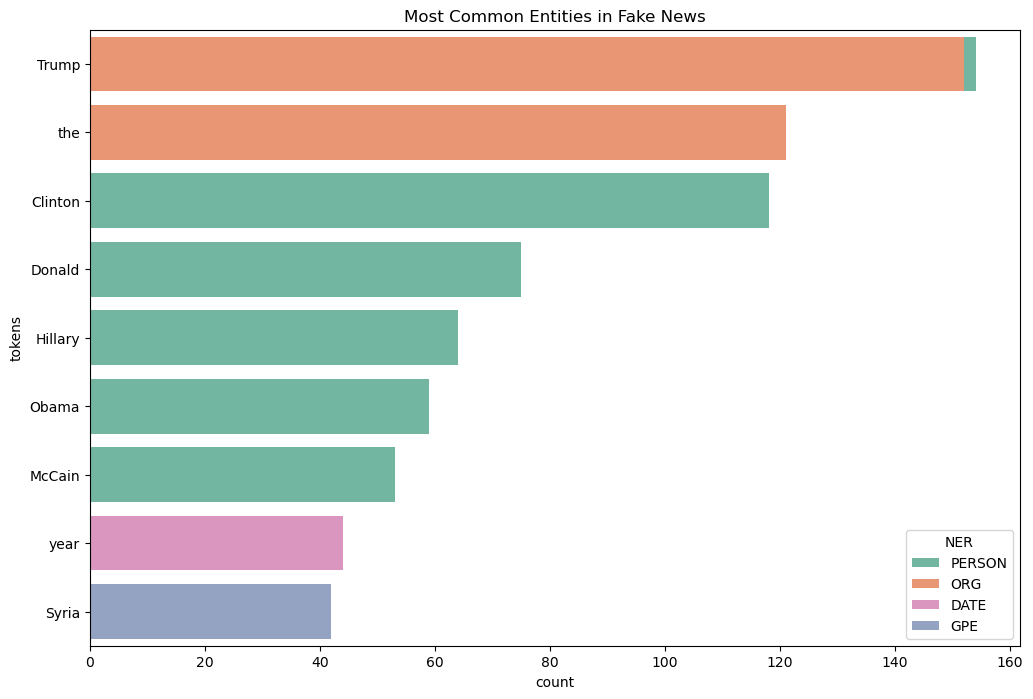

In [53]:
sns.barplot(
    data= fake_news_table_NER[0:10],
    x= 'count',
    y= 'tokens',
    hue= 'NER',
    orient= 'h',
    palette= ner_palette,
    dodge= False
).set(title = 'Most Common Entities in Fake News')

[Text(0.5, 1.0, 'Most Common Entities in Factual News')]

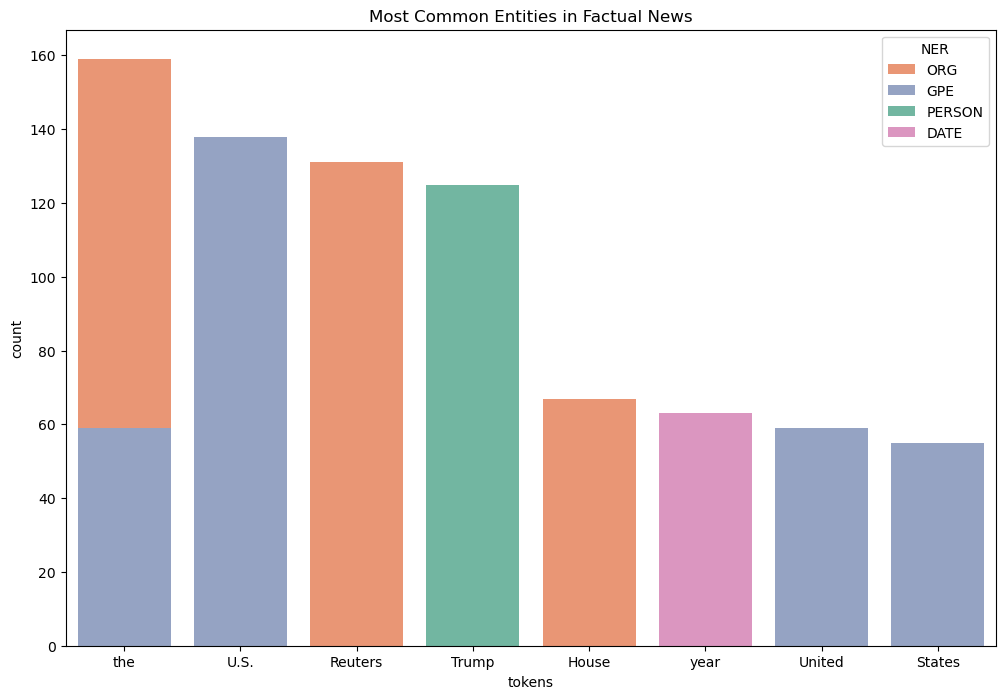

In [58]:
sns.barplot(
    data= factual_news_table_NER[0:10],
    x= 'tokens',
    y= 'count',
    hue= 'NER',
    orient= 'v',
    palette= ner_palette,
    dodge= False

    
).set(title ='Most Common Entities in Factual News')

In [61]:
pos_tags = ['NOUN', 'PROPN', 'VERB', 'ADP', 'PUNCT', 'DET', 'PRON', 
            'ADJ', 'AUX', 'ADV', 'PART', 'CCONJ', 'SPACE', 'SCONJ', 'NUM']

pos_colors = sns.color_palette("husl", n_colors=len(pos_tags)).as_hex()

pos_palette = dict(zip(pos_tags, pos_colors))

[Text(0.5, 1.0, 'Most Common POS in Fake News')]

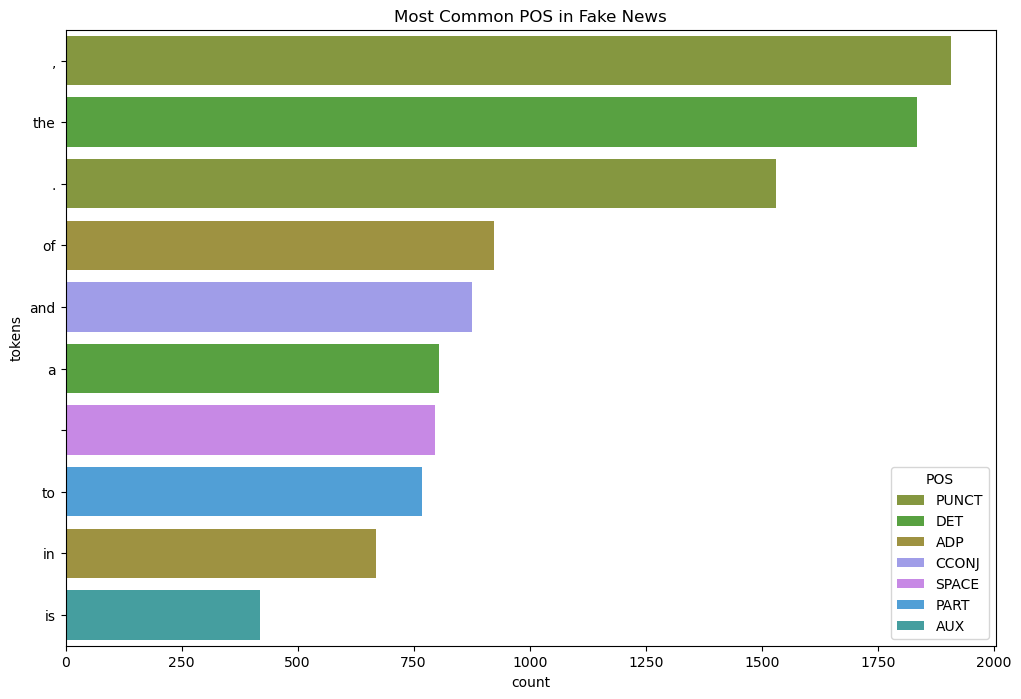

In [64]:
sns.barplot(
    data= fake_news_table_pos[0:10],
    x='count',
    y= 'tokens',
    hue= 'POS',
    palette= pos_palette,
    dodge= False
).set(title = 'Most Common POS in Fake News')

[Text(0.5, 1.0, 'Most Common POS in Factual News')]

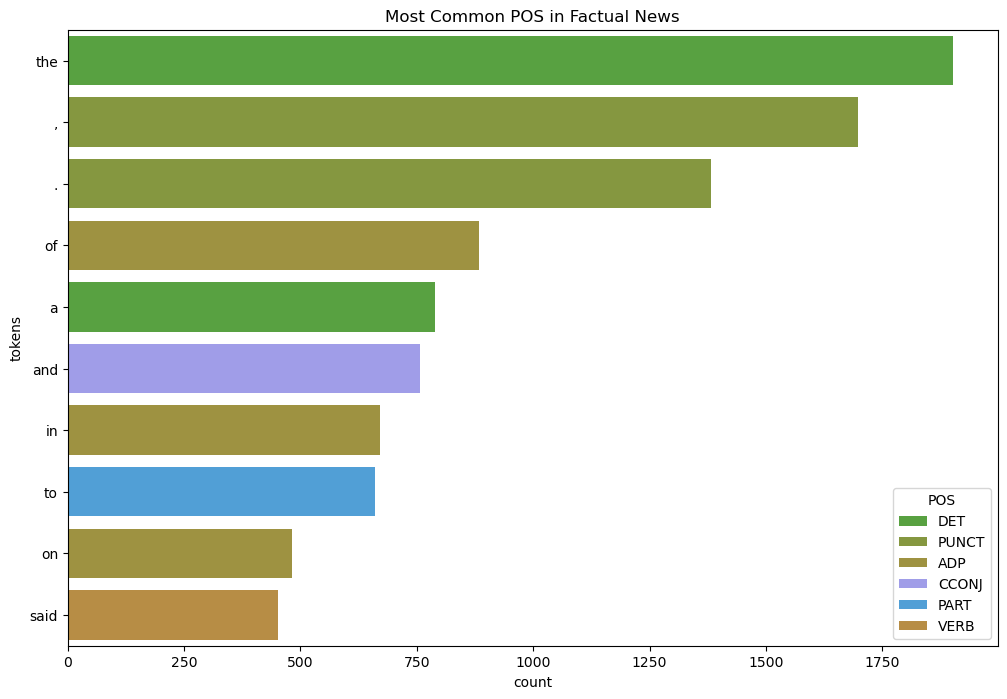

In [65]:
sns.barplot(
    data= factual_news_table_pos[0:10],
    x='count',
    y= 'tokens',
    hue= 'POS',
    palette= pos_palette,
    dodge= False
).set(title = 'Most Common POS in Factual News')